In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path



In [2]:
DATASET_PATH = Path("UCI-HAR-Dataset")

features = pd.read_csv(DATASET_PATH / "features.txt",sep=r'\s+', header=None, names=["idx", "feature"])
feature_names = features["feature"].values

has_duplicates = len(feature_names) != len(set(feature_names))
print(has_duplicates)

from collections import Counter


counts = Counter(feature_names)
duplicates = [item for item, count in counts.items() if count > 1]

print(len(duplicates))

True
42


In [26]:
activity_labels = pd.read_csv(DATASET_PATH / "activity_labels.txt",sep=r'\s+', header=None, names=["idx", "label"])
activity_labels["idx"] = activity_labels["idx"] - 1
activity_labels.head()


,idx,label
0,0,WALKING
1,1,WALKING_UPSTAIRS
2,2,WALKING_DOWNSTAIRS
3,3,SITTING
4,4,STANDING


In [4]:
activity_labels_list = activity_labels["label"].to_list()
activity_labels_list

['WALKING',
 'WALKING_UPSTAIRS',
 'WALKING_DOWNSTAIRS',
 'SITTING',
 'STANDING',
 'LAYING']

In [27]:
activity_map = dict(zip(activity_labels["idx"], activity_labels["label"]))
activity_map

{0: 'WALKING',
 1: 'WALKING_UPSTAIRS',
 2: 'WALKING_DOWNSTAIRS',
 3: 'SITTING',
 4: 'STANDING',
 5: 'LAYING'}

In [29]:
def load_data(split):

    base = DATASET_PATH / split

    X = pd.read_csv(base / f"X_{split}.txt",    sep=r'\s+', header=None)
    X.columns = feature_names
    y = pd.read_csv(base / f"y_{split}.txt",    sep=r'\s+', header=None, names=["activity_id"])
    s = pd.read_csv(base / f"subject_{split}.txt", sep=r'\s+', header=None, names=["subject"])
    X_combined = pd.concat([s, X], axis=1)
    return X_combined, y

X_train, y_train = load_data("train")
X_test, y_test = load_data("test")
y_train['activity_id'] = y_train['activity_id'] - 1
y_test['activity_id'] = y_test['activity_id'] - 1
y_train.head()



,activity_id
0,4
1,4
2,4
3,4
4,4


In [30]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)    
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)


In [31]:
y_train

,activity_id
0,4
1,4
2,4
3,4
4,4
...,...
7347,1
7348,1
7349,1
7350,1


In [18]:
y_train = y_train - 1
y_train.head()

,activity_id
0,3
1,3
2,3
3,3
4,3


In [11]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

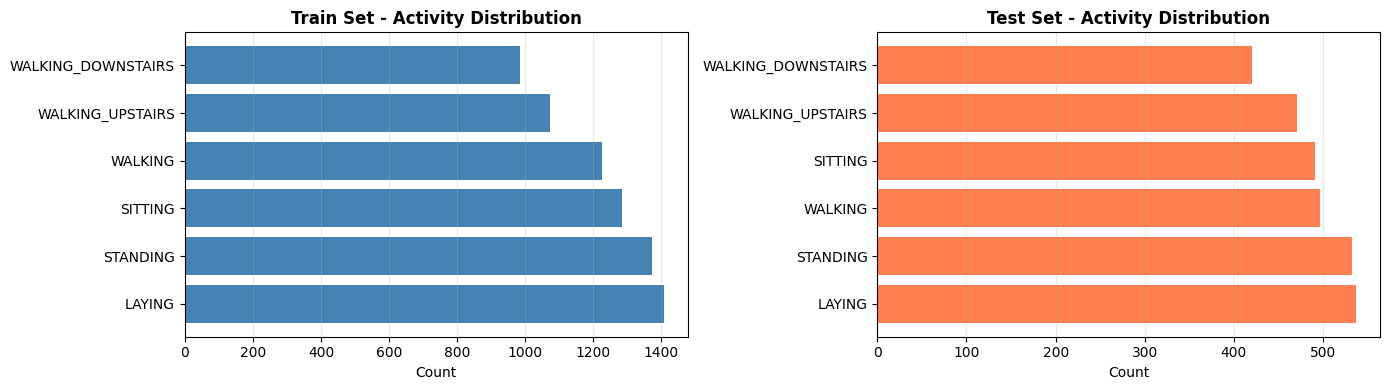

Train set size: 7352, Test set size: 2947


In [18]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

activity_counts_train = pd.Series(y_train).map(activity_map).value_counts()
axes[0].barh(activity_counts_train.index, activity_counts_train.values, color='steelblue')
axes[0].set_title('Train Set - Activity Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].grid(axis='x', alpha=0.3)

# Test set
activity_counts_test = pd.Series(y_test).map(activity_map).value_counts()
axes[1].barh(activity_counts_test.index, activity_counts_test.values, color='coral')
axes[1].set_title('Test Set - Activity Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Train set size: {len(y_train)}, Test set size: {len(y_test)}")

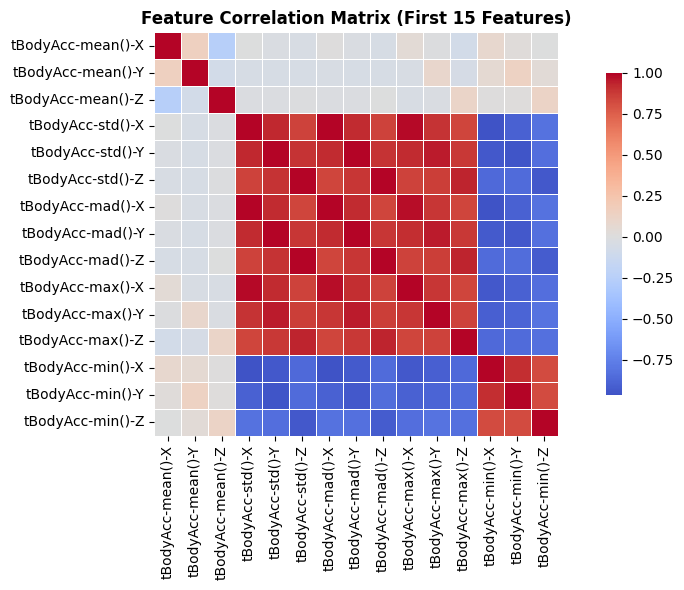


Dataset Overview:
- Train samples: 7352, Test samples: 2947
- Total features: 561
- Activities: 6
- Total subjects: 21


In [20]:
# Correlation heatmap - first 20 features
fig, ax = plt.subplots(figsize=(10, 6))

features_subset = X_train.drop('subject', axis=1).iloc[:, :15]  # First 15 features
correlation_matrix = features_subset.corr()

sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, ax=ax, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Matrix (First 15 Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nDataset Overview:")
print(f"- Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"- Total features: {len(feature_names)}")
print(f"- Activities: {len(activity_map)}")
print(f"- Total subjects: {X_train['subject'].nunique()}")

In [35]:

from models import get_models, train_and_evaluate

models = get_models()

In [36]:
results, trained_models = train_and_evaluate(models, X_train, y_train, X_test, y_test)

Training Decision Tree...
Trained Decision Tree in 3.88 seconds.
Training Random Forest...


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Trained Random Forest in 1.71 seconds.
Training Logistic Regression...


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Trained Logistic Regression in 3.65 seconds.
Training Linear SVC...


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Trained Linear SVC in 1.7 seconds.
Training RBF SVM...


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Trained RBF SVM in 0.92 seconds.
Training K-Nearest Neighbor...
Trained K-Nearest Neighbor in 0.02 seconds.


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [37]:
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df

,Model,Precision,Recall,F1-Score,Accuracy,Training Time
3,Linear SVC,0.97,0.97,0.96,0.97,1.70
2,Logistic Regression,0.96,0.96,0.96,0.96,3.65
4,RBF SVM,0.95,0.95,0.95,0.95,0.92
1,Random Forest,0.92,0.92,0.92,0.92,1.71
0,Decision Tree,0.86,0.86,0.86,0.86,3.88
5,K-Nearest Neighbor,0.82,0.81,0.81,0.81,0.02


In [25]:
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df.to_csv("baseline_results.csv", index=False)

In [31]:
from sklearn.metrics import classification_report

best_name = results_df.iloc[0]["Model"]
_, best_pred = trained_models[best_name]

print(f"\nDetailed report — {best_name}:\n")
print(classification_report(y_test, best_pred, target_names=activity_labels_list))


Detailed report — Linear SVC:

                    precision    recall  f1-score   support

           WALKING       0.97      0.99      0.98       496
  WALKING_UPSTAIRS       0.97      0.97      0.97       471
WALKING_DOWNSTAIRS       1.00      0.97      0.98       420
           SITTING       0.96      0.85      0.90       491
          STANDING       0.87      0.98      0.92       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



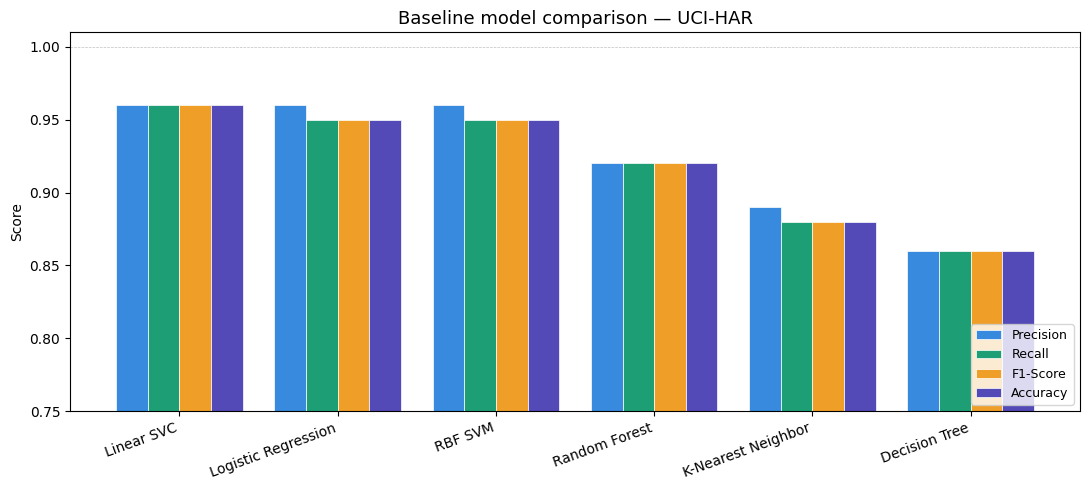

In [32]:
fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(results_df))
width = 0.2
metrics = ["Precision", "Recall", "F1-Score", "Accuracy"]
colors  = ["#378ADD", "#1D9E75", "#EF9F27", "#534AB7"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=color, edgecolor="white", linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"], rotation=20, ha="right", fontsize=10)
ax.set_ylim(0.75, 1.01)
ax.set_ylabel("Score")
ax.set_title("Baseline model comparison — UCI-HAR", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()